In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
%matplotlib.inline

UsageError: Line magic function `%matplotlib.inline` not found.


In [3]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)


In [4]:
X

array([[-1.86471247,  5.14198496],
       [-2.27386684,  2.95139454],
       [-3.55631469, -1.24250575],
       ...,
       [-2.99922546,  2.58671998],
       [ 1.48663844, -0.84900502],
       [-4.46886588, -2.22393237]], shape=(1000, 2))

In [5]:
y

array([1, 1, 2, 2, 1, 0, 2, 2, 0, 2, 1, 1, 0, 0, 2, 1, 2, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 2, 2, 0, 0, 0, 2, 0, 1, 1, 2, 2,
       2, 1, 2, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 2, 0, 1, 2,
       2, 1, 0, 0, 2, 1, 2, 0, 2, 1, 2, 2, 0, 2, 2, 0, 0, 2, 2, 1, 0, 0,
       1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 2, 2, 1, 0, 1, 0, 1, 0, 2, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 0, 1, 0, 0, 0, 1, 2, 1,
       0, 0, 2, 2, 0, 1, 0, 2, 2, 2, 1, 0, 2, 0, 2, 0, 0, 0, 2, 2, 2, 1,
       0, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 2, 2, 1, 0, 2, 0, 0, 1, 0, 1, 0,
       2, 2, 1, 1, 2, 1, 1, 0, 1, 2, 1, 1, 2, 2, 0, 2, 1, 2, 1, 1, 2, 0,
       1, 0, 1, 0, 0, 0, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0, 2, 2, 1, 1, 1, 0,
       0, 1, 2, 1, 2, 2, 1, 1, 1, 2, 1, 2, 2, 0, 0, 0, 2, 1, 2, 0, 1, 0,
       0, 0, 1, 2, 2, 1, 1, 2, 1, 2, 2, 1, 0, 1, 0, 0, 2, 2, 2, 1, 0, 1,
       1, 2, 2, 1, 2, 2, 0, 1, 0, 2, 2, 0, 1, 2, 0, 2, 0, 2, 2, 0, 1, 2,
       1, 0, 2, 0, 1, 0, 0, 1, 2, 0, 1, 1, 2, 1, 1,

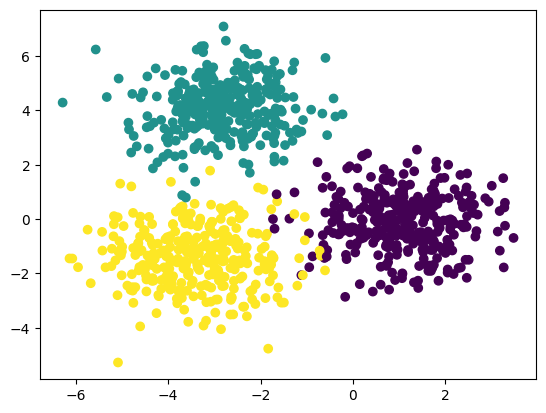

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
## Standardization feature scaling

from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [9]:
X_train_scaled=scalar.fit_transform(X_train)

In [10]:
X_test_scaled=scalar.transform(X_test)

In [11]:
from sklearn.cluster import KMeans

In [12]:
## Elbow Method to select k value

wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)

In [13]:
wcss

[1340.0,
 707.7858721025668,
 237.66305010787133,
 205.1367378709361,
 177.4597021498532,
 150.43816495800894,
 133.4287608763569,
 119.45927421311279,
 112.83773807928418,
 96.69987550570735]

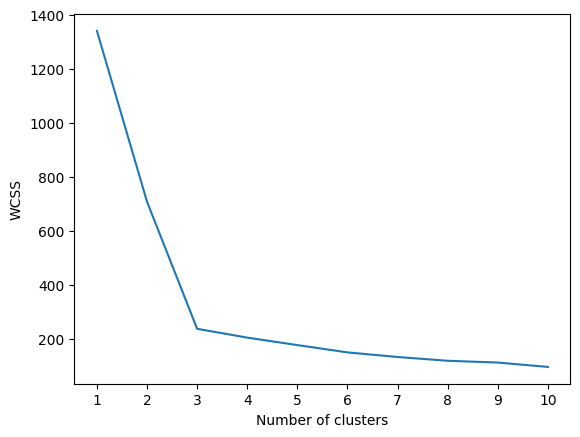

In [14]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [15]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [16]:
kmeans.fit_predict(X_train_scaled)

array([0, 1, 2, 1, 0, 0, 0, 0, 2, 1, 0, 2, 0, 0, 1, 2, 1, 2, 0, 1, 0, 2,
       0, 1, 1, 0, 0, 0, 1, 2, 1, 0, 2, 0, 1, 1, 1, 1, 1, 1, 2, 0, 2, 1,
       2, 2, 1, 1, 1, 0, 2, 1, 2, 1, 1, 2, 0, 1, 0, 2, 2, 0, 2, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 2, 1, 1, 1, 1, 0, 0, 0, 1, 1, 2,
       0, 2, 0, 0, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 2, 2, 1, 0, 1, 0, 2,
       0, 0, 1, 0, 1, 0, 0, 2, 1, 2, 0, 0, 1, 1, 0, 0, 2, 0, 0, 1, 2, 0,
       2, 1, 1, 1, 0, 1, 2, 0, 0, 2, 1, 2, 2, 0, 0, 2, 1, 1, 2, 0, 0, 1,
       2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 1, 1, 2, 2, 2, 2, 1, 2,
       1, 0, 2, 2, 1, 0, 0, 0, 2, 1, 2, 0, 1, 1, 0, 2, 2, 0, 1, 2, 1, 1,
       0, 2, 2, 1, 0, 0, 1, 0, 0, 0, 0, 1, 2, 0, 2, 2, 0, 0, 2, 1, 2, 1,
       0, 2, 2, 0, 0, 2, 1, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 2, 0, 2, 1, 2,
       2, 0, 0, 2, 0, 0, 2, 1, 0, 1, 1, 0, 1, 1, 2, 0, 2, 1, 2, 2, 2, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 2, 0, 1, 0, 2, 2, 2, 1, 1, 1, 2, 1,
       1, 1, 1, 0, 0, 2, 0, 1, 2, 2, 0, 2, 0, 0, 0,

In [17]:
y_pred=kmeans.predict(X_test_scaled)

In [19]:
y_pred

array([2, 1, 2, 1, 2, 0, 2, 1, 0, 1, 0, 2, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0,
       2, 2, 2, 1, 0, 0, 2, 2, 2, 2, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 2, 2, 2, 2, 1, 1, 2, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 2, 2, 2, 2, 1, 0, 2, 1, 1, 1, 1, 0, 0, 1, 2, 1, 0, 1, 1, 1, 2,
       2, 0, 1, 0, 2, 0, 0, 0, 1, 0, 1, 2, 2, 1, 1, 1, 1, 0, 2, 0, 1, 2,
       1, 0, 2, 2, 1, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 1, 0, 2, 0, 1, 0, 1,
       2, 2, 2, 2, 1, 2, 0, 2, 2, 0, 2, 2, 2, 2, 1, 0, 2, 0, 1, 0, 2, 1,
       1, 1, 1, 1, 0, 0, 0, 2, 0, 0, 1, 1, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2,
       1, 2, 0, 2, 0, 2, 1, 1, 1, 0, 1, 1, 0, 2, 1, 0, 2, 1, 1, 0, 1, 2,
       2, 1, 0, 2, 0, 2, 2, 1, 2, 1, 1, 2, 2, 2, 1, 1, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 0, 2, 2, 0, 2, 0, 0, 1, 2, 2, 2, 0, 2, 0, 0, 1, 2, 1,
       0, 0, 0, 0, 1, 2, 2, 0, 1, 1, 1, 0, 1, 2, 1, 1, 0, 1, 1, 1, 0, 2,
       2, 1, 1, 2, 0, 2, 0, 1, 2, 0, 2, 2, 2, 2, 1, 0, 0, 1, 1, 0, 1, 2,
       2, 2, 0, 1, 2, 0, 2, 2, 2, 0, 2, 1, 2, 2, 0,

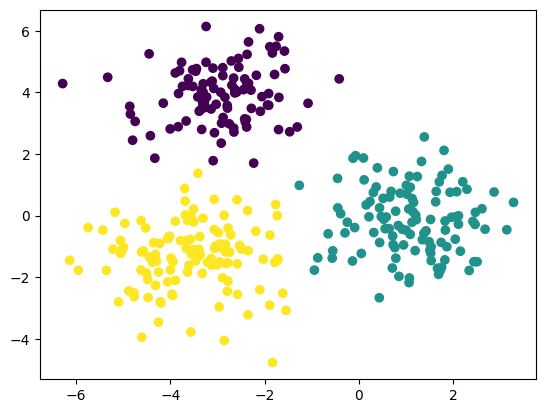

In [20]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [21]:
#validating the k value
# kneelocator
# silhoutte scoring

In [22]:
#kneelocator

!pip install kneed


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from kneed import KneeLocator


In [26]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [27]:
kl.elbow

np.int64(3)

In [28]:
## silhoutte scoring

from sklearn.metrics import silhouette_score

In [30]:
silhouette_coeff=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(X_train_scaled)
  score=silhouette_score(X_train_scaled,kmeans.labels_)
  silhouette_coeff.append(score)

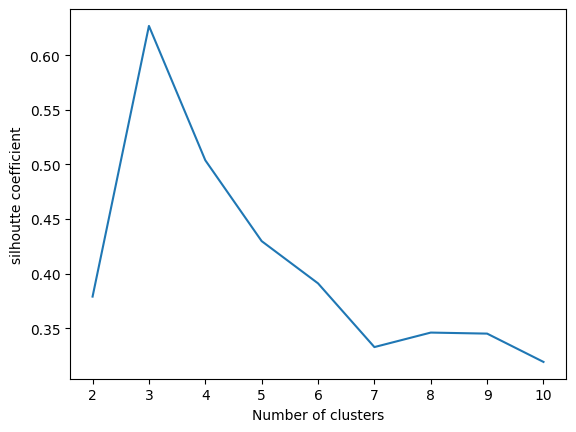

In [32]:
## plot elbow curve
plt.plot(range(2,11),silhouette_coeff)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("silhoutte coefficient")
plt.show()